# Oral Diseases Image Classification

Objective: build, compare and deploy a CNN based system that classifies oral disease images into their correct category. This notebook covers a custom CNN trained from scratch, three pretrained backbones fine tuned on the dataset, hyperparameter tuning on the best backbone, a comparative analysis of every model, and a Streamlit deployment app for the final chosen model.

This version is built to survive a disconnected Colab runtime. Every expensive step (dataset download and split, every model's training) checks Google Drive first and skips itself if that step already finished in a previous session, and training resumes from the last completed epoch instead of starting over. If the runtime stops for any reason, just reconnect and Runtime > Run all again. It will pick up where it left off on its own.

## Mount Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os

SAVE_DIR = "/content/drive/MyDrive/oral_disease_project"
os.makedirs(SAVE_DIR, exist_ok=True)
print("Saving everything to:", SAVE_DIR)

Mounted at /content/drive
Saving everything to: /content/drive/MyDrive/oral_disease_project


## Setup

In [ ]:
import cv2
import json
import time
import random
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.callbacks import ReduceLROnPlateau, ModelCheckpoint, Callback

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support

import warnings
warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Dataset (download once, reuse from Drive after that)

In [ ]:
SPLIT_DIR = "/content/oral_dataset_split"
SPLIT_ZIP = f"{SAVE_DIR}/oral_dataset_split.zip"

# only these 6 are real disease classes. anything else found under the dataset
# root, such as the YOLO detection annotated-dataset folder that bundles
# several diseases together for a different task, gets skipped on purpose.
NAME_MAP = {
    "calculus": "Calculus",
    "gingivitis": "Gingivitis",
    "hypodontia": "Hypodontia",
    "data caries": "Caries",
    "caries": "Caries",
    "mouth ulcer": "Ulcers",
    "tooth discoloration": "Tooth_Discoloration",
}
EXPECTED_CLASSES = sorted(set(NAME_MAP.values()))


def split_is_valid(split_dir):
    # checks the split actually has all 6 real classes with real images in
    # every split, rather than just trusting that a zip file existed.
    train_dir = os.path.join(split_dir, "train")
    if not os.path.isdir(train_dir):
        return False, "train folder missing"
    found_classes = sorted(os.listdir(train_dir))
    if found_classes != EXPECTED_CLASSES:
        return False, f"found classes {found_classes}, expected {EXPECTED_CLASSES}"
    for split in ["train", "val", "test"]:
        for class_name in EXPECTED_CLASSES:
            class_dir = os.path.join(split_dir, split, class_name)
            if not os.path.isdir(class_dir) or len(os.listdir(class_dir)) == 0:
                return False, f"{split}/{class_name} is missing or empty"
    return True, "ok"


def build_dataset_from_scratch():
    print("Building dataset from scratch (downloading, filtering, splitting)...")

    import kagglehub
    path = kagglehub.dataset_download("salmansajid05/oral-diseases")
    print("Raw top-level folders found by kagglehub:", os.listdir(path))

    IMG_EXTS = (".jpg", ".jpeg", ".png", ".bmp")

    def find_images(folder):
        found = []
        for root, _, files in os.walk(folder):
            for f in files:
                if f.lower().endswith(IMG_EXTS):
                    found.append(os.path.join(root, f))
        return found

    CLEAN_DIR = "/content/oral_dataset"
    if os.path.exists(CLEAN_DIR):
        shutil.rmtree(CLEAN_DIR)
    os.makedirs(CLEAN_DIR, exist_ok=True)

    class_counts_local = {}
    for entry in sorted(os.listdir(path)):
        folder_path = os.path.join(path, entry)
        if not os.path.isdir(folder_path):
            continue
        key = entry.strip().lower()
        if key not in NAME_MAP:
            print(f"Skipping non-class folder: {entry}")
            continue
        class_name = NAME_MAP[key]
        dest_dir = os.path.join(CLEAN_DIR, class_name)
        os.makedirs(dest_dir, exist_ok=True)
        images = find_images(folder_path)
        for i, img_path in enumerate(images):
            ext = os.path.splitext(img_path)[1].lower()
            dest_path = os.path.join(dest_dir, f"{class_name}_{i}{ext}")
            try:
                shutil.copyfile(img_path, dest_path)
            except Exception:
                pass
        n_saved = len(os.listdir(dest_dir))
        class_counts_local[class_name] = n_saved
        print(f"{class_name:<20} {n_saved} images")

    assert len(class_counts_local) == 6, (
        f"Expected 6 classes, got {len(class_counts_local)}: {list(class_counts_local.keys())}. "
        "Check the raw folders printed above and update NAME_MAP if the dataset structure changed."
    )
    assert sum(class_counts_local.values()) > 0, "No images were found at all."

    if os.path.exists(SPLIT_DIR):
        shutil.rmtree(SPLIT_DIR)

    SPLITS = ["train", "val", "test"]
    for split in SPLITS:
        for class_name in class_counts_local.keys():
            os.makedirs(os.path.join(SPLIT_DIR, split, class_name), exist_ok=True)

    for class_name in class_counts_local.keys():
        src_dir = os.path.join(CLEAN_DIR, class_name)
        files = [os.path.join(src_dir, f) for f in os.listdir(src_dir)]
        train_files, temp_files = train_test_split(files, test_size=0.3, random_state=SEED)
        val_files, test_files = train_test_split(temp_files, test_size=0.5, random_state=SEED)
        for split, split_files in zip(SPLITS, [train_files, val_files, test_files]):
            for f in split_files:
                shutil.copy(f, os.path.join(SPLIT_DIR, split, class_name, os.path.basename(f)))

    is_valid, reason = split_is_valid(SPLIT_DIR)
    assert is_valid, f"Split failed validation right after building it: {reason}"

    if os.path.exists(SPLIT_ZIP):
        os.remove(SPLIT_ZIP)
    print("Saving split dataset to Drive so this step never has to run again...")
    shutil.make_archive(SPLIT_ZIP.replace(".zip", ""), "zip", "/content", "oral_dataset_split")
    print("Saved:", SPLIT_ZIP)


if os.path.exists(SPLIT_ZIP):
    print("Found a split dataset zip in Drive, trying it first...")
    if os.path.exists(SPLIT_DIR):
        shutil.rmtree(SPLIT_DIR)
    shutil.unpack_archive(SPLIT_ZIP, "/content")
    is_valid, reason = split_is_valid(SPLIT_DIR)
    if is_valid:
        print("Existing split is valid, reusing it. No download needed.")
    else:
        print(f"Existing split failed validation ({reason}), rebuilding from scratch instead of trusting it.")
        build_dataset_from_scratch()
else:
    print("No saved split found in Drive, building it now...")
    build_dataset_from_scratch()

is_valid, reason = split_is_valid(SPLIT_DIR)
assert is_valid, f"Dataset split is still not valid after the build step: {reason}"
print("Dataset ready and verified: 6 real classes, every split populated.")

Found a split dataset zip in Drive, trying it first...
Existing split is valid, reusing it. No download needed.
Dataset ready and verified: 6 real classes, every split populated.


Calculus             train=907   val=194   test=195
Caries               train=1820  val=390   test=391
Gingivitis           train=1644  val=352   test=353
Hypodontia           train=875   val=188   test=188
Tooth_Discoloration  train=1411  val=303   test=303
Ulcers               train=1964  val=421   test=421


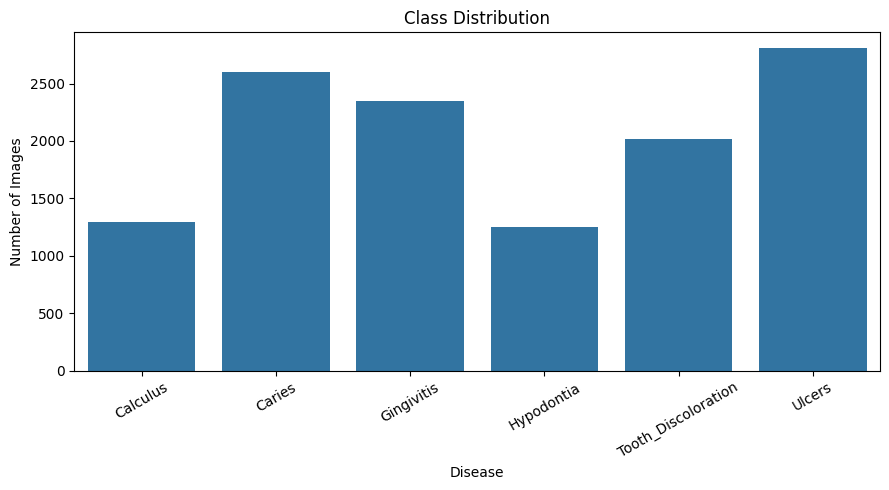

In [ ]:
class_counts = {}
for class_name in sorted(os.listdir(os.path.join(SPLIT_DIR, "train"))):
    n_train = len(os.listdir(os.path.join(SPLIT_DIR, "train", class_name)))
    n_val = len(os.listdir(os.path.join(SPLIT_DIR, "val", class_name)))
    n_test = len(os.listdir(os.path.join(SPLIT_DIR, "test", class_name)))
    class_counts[class_name] = n_train + n_val + n_test
    print(f"{class_name:<20} train={n_train:<5} val={n_val:<5} test={n_test}")

plt.figure(figsize=(9, 5))
sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()))
plt.title("Class Distribution")
plt.xlabel("Disease")
plt.ylabel("Number of Images")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = image_dataset_from_directory(
    os.path.join(SPLIT_DIR, "train"), image_size=IMG_SIZE, batch_size=BATCH_SIZE, seed=SEED, shuffle=True,
)
val_ds = image_dataset_from_directory(
    os.path.join(SPLIT_DIR, "val"), image_size=IMG_SIZE, batch_size=BATCH_SIZE, seed=SEED, shuffle=False,
)
test_ds = image_dataset_from_directory(
    os.path.join(SPLIT_DIR, "test"), image_size=IMG_SIZE, batch_size=BATCH_SIZE, seed=SEED, shuffle=False,
)

class_names = train_ds.class_names
NUM_CLASSES = len(class_names)
print(class_names)

Found 8621 files belonging to 6 classes.
Found 1848 files belonging to 6 classes.
Found 1851 files belonging to 6 classes.
['Calculus', 'Caries', 'Gingivitis', 'Hypodontia', 'Tooth_Discoloration', 'Ulcers']


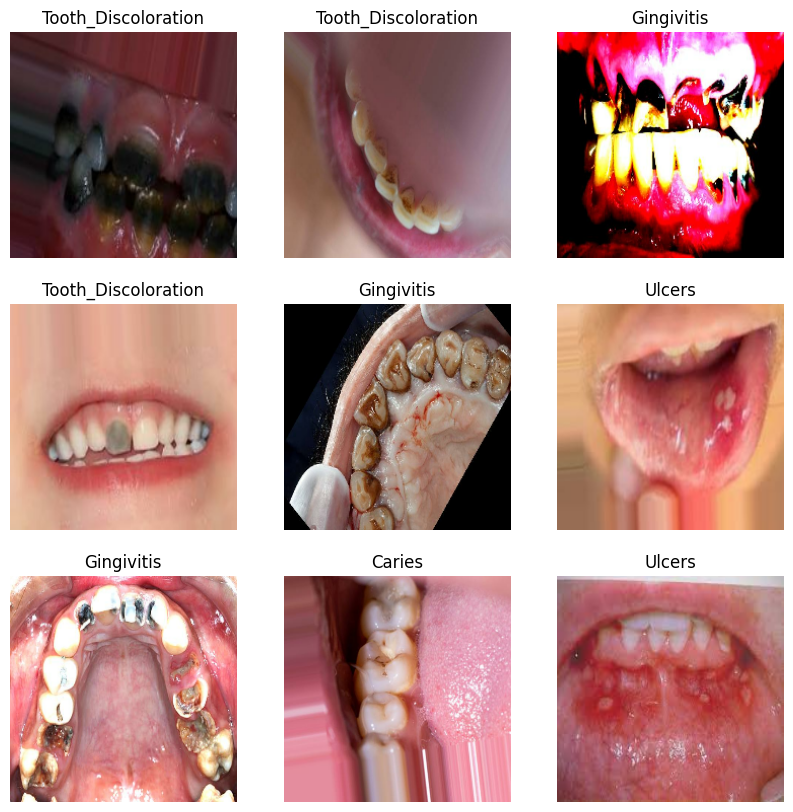

In [ ]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.show()

In [ ]:
train_labels = []
for _, labels in train_ds.unbatch():
    train_labels.append(labels.numpy())

class_weight_values = compute_class_weight(
    class_weight="balanced", classes=np.unique(train_labels), y=train_labels,
)
class_weight_dict = {i: w for i, w in enumerate(class_weight_values)}
class_weight_dict

{0: np.float64(1.5841602352076443),
 1: np.float64(0.7894688644688644),
 2: np.float64(0.8739862124898621),
 3: np.float64(1.642095238095238),
 4: np.float64(1.0183085282305693),
 5: np.float64(0.7315852002715546)}

In [ ]:

CACHE_DIR = "/content/tf_cache"
shutil.rmtree(CACHE_DIR, ignore_errors=True)
os.makedirs(CACHE_DIR, exist_ok=True)

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache(f"{CACHE_DIR}/train").shuffle(1000, seed=SEED).prefetch(AUTOTUNE)
val_ds = val_ds.cache(f"{CACHE_DIR}/val").prefetch(AUTOTUNE)
test_ds = test_ds.cache(f"{CACHE_DIR}/test").prefetch(AUTOTUNE)

In [ ]:
img_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.15),
        layers.RandomZoom(0.15),
        layers.RandomContrast(0.15),
        layers.RandomTranslation(0.1, 0.1),
    ],
    name="img_augmentation",
)

## Resumable training helper

This is the piece that makes the whole notebook safe to Run all at any point. Every training stage saves its model and its last completed epoch number to Drive after each epoch. If this cell's function is called again after a restart, it loads the saved model and continues from that epoch instead of starting over. If a stage already reached its target epoch count, it is skipped entirely.

In [ ]:
class EpochLogger(Callback):
    def __init__(self, log_path):
        super().__init__()
        self.log_path = log_path

    def on_epoch_end(self, epoch, logs=None):
        with open(self.log_path, "w") as f:
            f.write(str(epoch + 1))


def get_last_epoch(log_path):
    if os.path.exists(log_path):
        try:
            return int(open(log_path).read().strip())
        except Exception:
            return 0
    return 0


def resumable_fit(model, stage_name, epochs, lr=None, extra_callbacks=None):
    ckpt_path = f"{SAVE_DIR}/{stage_name}.keras"
    log_path = f"{SAVE_DIR}/{stage_name}_epoch.txt"

    if os.path.exists(ckpt_path):
        print(f"[{stage_name}] found checkpoint in Drive, loading it")
        model = tf.keras.models.load_model(ckpt_path)

    last_epoch = get_last_epoch(log_path)

    if last_epoch >= epochs:
        print(f"[{stage_name}] already finished ({last_epoch}/{epochs} epochs), skipping training")
        return model, None

    print(f"[{stage_name}] training epochs {last_epoch} -> {epochs}")

    if lr is not None:
        model.compile(optimizer=tf.keras.optimizers.Adam(lr), loss="sparse_categorical_crossentropy", metrics=["accuracy"])

    callbacks = [
        ModelCheckpoint(ckpt_path, save_best_only=False, save_freq="epoch"),
        EpochLogger(log_path),
        ReduceLROnPlateau(monitor="val_loss", factor=0.2, patience=3),
    ]
    if extra_callbacks:
        callbacks += extra_callbacks

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        initial_epoch=last_epoch,
        class_weight=class_weight_dict,
        callbacks=callbacks,
    )
    return model, history

In [ ]:
def get_backbone_layer(model):
    for layer in model.layers:
        if isinstance(layer, tf.keras.Model):
            return layer
    raise ValueError("No backbone sub-model found in this model")

## Reusable evaluation helper

In [ ]:
def get_true_and_pred(model, dataset):
    y_true, y_pred = [], []
    for images, labels in dataset:
        preds = model.predict(images, verbose=0)
        y_true.extend(labels.numpy())
        y_pred.extend(np.argmax(preds, axis=1))
    return np.array(y_true), np.array(y_pred)


def evaluate_model(model, dataset, class_names, name):
    y_true, y_pred = get_true_and_pred(model, dataset)

    print(f"\n=== Classification report: {name} ===")
    print(classification_report(y_true, y_pred, target_names=class_names))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 7))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted")
    accuracy = (y_true == y_pred).mean()

    return {"model": name, "accuracy": accuracy, "precision": precision, "recall": recall, "f1": f1}


def plot_history(history, name):
    if history is None:
        print(f"[{name}] nothing new to plot, this stage was already finished")
        return
    acc = history.history["accuracy"]
    val_acc = history.history["val_accuracy"]
    loss = history.history["loss"]
    val_loss = history.history["val_loss"]

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(acc, label="Train")
    plt.plot(val_acc, label="Validation")
    plt.title(f"{name} - Accuracy")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(loss, label="Train")
    plt.plot(val_loss, label="Validation")
    plt.title(f"{name} - Loss")
    plt.legend()
    plt.tight_layout()
    plt.show()

## Custom CNN (trained from scratch)

In [ ]:
def build_custom_cnn(input_shape=(224, 224, 3), num_classes=NUM_CLASSES):
    inputs = layers.Input(shape=input_shape)
    x = img_augmentation(inputs)
    x = layers.Rescaling(1.0 / 255)(x)

    x = layers.Conv2D(32, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.Conv2D(256, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D()(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    return Model(inputs, outputs, name="custom_cnn")

custom_cnn = build_custom_cnn()
custom_cnn.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
custom_cnn.summary()

Model: "custom_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ img_augmentation (Sequential)   │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 457,670 (1.75 MB)

 Trainable params: 456,710 (1.74 MB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, json, gc, shutil, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.applications import EfficientNetB0, ResNet50V2, DenseNet121
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_preprocess
from tensorflow.keras.applications.resnet_v2 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.densenet import preprocess_input as dense_preprocess
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support

SEED = 42
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SAVE_DIR = "/content/drive/MyDrive/oral_disease_project"
SPLIT_DIR = "/content/oral_dataset_split"
SPLIT_ZIP = f"{SAVE_DIR}/oral_dataset_split.zip"

tf.random.set_seed(SEED)
np.random.seed(SEED)

if not os.path.exists(os.path.join(SPLIT_DIR, "train")):
    shutil.unpack_archive(SPLIT_ZIP, "/content")

train_ds = image_dataset_from_directory(os.path.join(SPLIT_DIR, "train"), image_size=IMG_SIZE, batch_size=BATCH_SIZE, seed=SEED, shuffle=True)
val_ds   = image_dataset_from_directory(os.path.join(SPLIT_DIR, "val"),   image_size=IMG_SIZE, batch_size=BATCH_SIZE, seed=SEED, shuffle=False)
test_ds  = image_dataset_from_directory(os.path.join(SPLIT_DIR, "test"),  image_size=IMG_SIZE, batch_size=BATCH_SIZE, seed=SEED, shuffle=False)

class_names = train_ds.class_names
NUM_CLASSES = len(class_names)
print("Classes:", class_names)

train_labels = np.concatenate([y.numpy() for _, y in train_ds], axis=0)
class_weight_dict = {i: w for i, w in enumerate(
    compute_class_weight("balanced", classes=np.unique(train_labels), y=train_labels))}

CACHE_DIR = "/content/tf_cache"
os.makedirs(CACHE_DIR, exist_ok=True)
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache(f"{CACHE_DIR}/train").shuffle(200, seed=SEED).prefetch(AUTOTUNE)
val_ds   = val_ds.cache(f"{CACHE_DIR}/val").prefetch(AUTOTUNE)
test_ds  = test_ds.cache(f"{CACHE_DIR}/test").prefetch(AUTOTUNE)

img_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.15),
    layers.RandomTranslation(0.1, 0.1),
], name="img_augmentation")

BACKBONES = {
    "EfficientNetB0": (EfficientNetB0, eff_preprocess),
    "ResNet50V2": (ResNet50V2, resnet_preprocess),
    "DenseNet121": (DenseNet121, dense_preprocess),
}
HEAD_EPOCHS = 10
FINE_EPOCHS = 10
FINE_TUNE_AT = 40


class EpochLogger(tf.keras.callbacks.Callback):
    def __init__(self, log_path):
        super().__init__()
        self.log_path = log_path
    def on_epoch_end(self, epoch, logs=None):
        with open(self.log_path, "w") as f:
            f.write(str(epoch + 1))


class MemoryCleanup(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        gc.collect()


def get_last_epoch(log_path):
    if os.path.exists(log_path):
        try:
            return int(open(log_path).read().strip())
        except Exception:
            return 0
    return 0


def get_backbone_layer(model):
    for layer in model.layers:
        if isinstance(layer, tf.keras.Model):
            return layer
    raise ValueError("No backbone sub-model found")


def resumable_fit(model, stage_name, epochs, lr=None):
    ckpt_path = f"{SAVE_DIR}/{stage_name}.keras"
    log_path = f"{SAVE_DIR}/{stage_name}_epoch.txt"
    if os.path.exists(ckpt_path):
        print(f"[{stage_name}] loading checkpoint from Drive")
        model = tf.keras.models.load_model(ckpt_path)
    last_epoch = get_last_epoch(log_path)
    if last_epoch >= epochs:
        print(f"[{stage_name}] already finished ({last_epoch}/{epochs}), skipping")
        return model, None
    print(f"[{stage_name}] training epochs {last_epoch} -> {epochs}")
    if lr is not None:
        model.compile(optimizer=tf.keras.optimizers.Adam(lr),
                      loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    callbacks = [
        tf.keras.callbacks.ModelCheckpoint(ckpt_path, save_best_only=False, save_freq="epoch"),
        EpochLogger(log_path),
        MemoryCleanup(),
        tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.2, patience=3),
    ]
    history = model.fit(train_ds, validation_data=val_ds, epochs=epochs,
                        initial_epoch=last_epoch, class_weight=class_weight_dict,
                        callbacks=callbacks)
    return model, history


def build_custom_cnn(input_shape=(224, 224, 3), num_classes=NUM_CLASSES):
    inputs = layers.Input(shape=input_shape)
    x = img_augmentation(inputs)
    x = layers.Rescaling(1.0 / 255)(x)
    for filters in [32, 64, 128, 256]:
        x = layers.Conv2D(filters, 3, padding="same", activation="relu")(x)
        x = layers.BatchNormalization()(x)
        x = layers.MaxPooling2D()(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    return Model(inputs, outputs, name="custom_cnn")


def build_transfer_model(base_fn, preprocess_fn, num_classes=NUM_CLASSES, dropout=0.3, dense_units=256):
    base_model = base_fn(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
    base_model.trainable = False
    inputs = layers.Input(shape=(224, 224, 3))
    x = img_augmentation(inputs)
    x = preprocess_fn(x)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(dense_units, activation="relu")(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    return Model(inputs, outputs)


def train_backbone(name, base_fn, preprocess_fn):
    head_ckpt = f"{SAVE_DIR}/{name}_head.keras"
    fine_ckpt = f"{SAVE_DIR}/{name}_fine.keras"
    if os.path.exists(fine_ckpt) and get_last_epoch(f"{SAVE_DIR}/{name}_fine_epoch.txt") >= FINE_EPOCHS:
        print(f"[{name}] fine tune already complete, loading")
        return tf.keras.models.load_model(fine_ckpt), None
    if os.path.exists(head_ckpt):
        model = tf.keras.models.load_model(head_ckpt)
    else:
        model = build_transfer_model(base_fn, preprocess_fn)
        model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                      loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    model, _ = resumable_fit(model, f"{name}_head", epochs=HEAD_EPOCHS)
    if os.path.exists(fine_ckpt):
        model = tf.keras.models.load_model(fine_ckpt)
    else:
        backbone = get_backbone_layer(model)
        backbone.trainable = True
        for layer in backbone.layers[:-FINE_TUNE_AT]:
            layer.trainable = False
        model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
                      loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    model, hist_fine = resumable_fit(model, f"{name}_fine", epochs=FINE_EPOCHS)
    return model, hist_fine


def get_true_and_pred(model, dataset):
    y_true, y_pred = [], []
    for images, labels in dataset:
        preds = model.predict(images, verbose=0)
        y_true.extend(labels.numpy())
        y_pred.extend(np.argmax(preds, axis=1))
    return np.array(y_true), np.array(y_pred)


def evaluate_model(model, dataset, class_names, name, show_plot=True):
    y_true, y_pred = get_true_and_pred(model, dataset)
    print(f"\n=== Classification report: {name} ===")
    print(classification_report(y_true, y_pred, target_names=class_names))
    if show_plot:
        cm = confusion_matrix(y_true, y_pred)
        plt.figure(figsize=(8, 7))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                    xticklabels=class_names, yticklabels=class_names)
        plt.title(f"Confusion Matrix - {name}")
        plt.xlabel("Predicted"); plt.ylabel("Actual")
        plt.tight_layout(); plt.show()
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted")
    return {"model": name, "accuracy": (y_true == y_pred).mean(),
            "precision": precision, "recall": recall, "f1": f1}


def plot_history(history, name):
    if history is None:
        print(f"[{name}] nothing new to plot")
        return
    h = history.history
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(h["accuracy"], label="Train"); plt.plot(h["val_accuracy"], label="Validation")
    plt.title(f"{name} - Accuracy"); plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(h["loss"], label="Train"); plt.plot(h["val_loss"], label="Validation")
    plt.title(f"{name} - Loss"); plt.legend()
    plt.tight_layout(); plt.show()


custom_cnn = build_custom_cnn()
custom_cnn.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                   loss="sparse_categorical_crossentropy", metrics=["accuracy"])

gc.collect()
print("\nEverything is loaded. Continue from the custom CNN training cell.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 8621 files belonging to 6 classes.
Found 1848 files belonging to 6 classes.
Found 1851 files belonging to 6 classes.
Classes: ['Calculus', 'Caries', 'Gingivitis', 'Hypodontia', 'Tooth_Discoloration', 'Ulcers']

Everything is loaded. Continue from the custom CNN training cell.


[custom_cnn] loading checkpoint from Drive
[custom_cnn] training epochs 39 -> 40
Epoch 40/40
270/270 ━━━━━━━━━━━━━━━━━━━━ 69s 161ms/step - accuracy: 0.9342 - loss: 0.1671 - val_accuracy: 0.8734 - val_loss: 0.3595 - learning_rate: 8.0000e-06


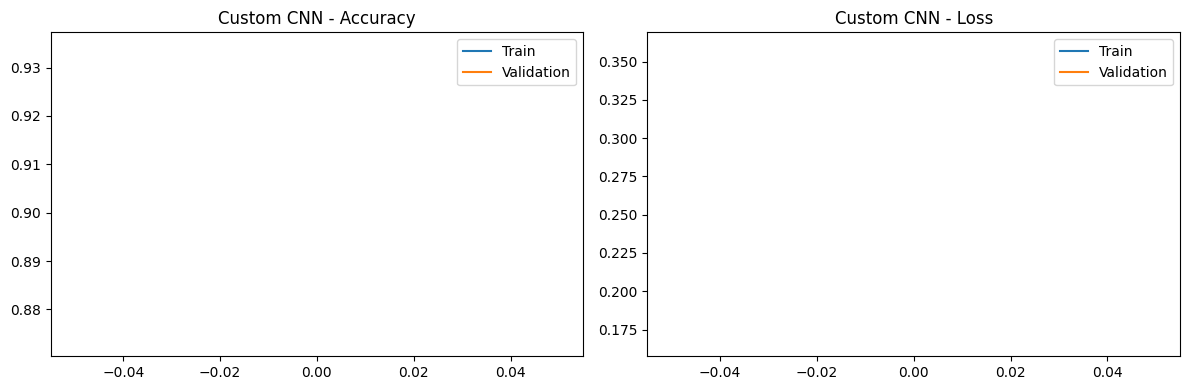

In [ ]:
custom_cnn, hist_cnn = resumable_fit(custom_cnn, "custom_cnn", epochs=40)
plot_history(hist_cnn, "Custom CNN")


=== Classification report: Custom CNN ===
                     precision    recall  f1-score   support

           Calculus       0.57      0.74      0.64       195
             Caries       1.00      0.81      0.89       391
         Gingivitis       0.81      0.73      0.77       353
         Hypodontia       0.77      0.96      0.85       188
Tooth_Discoloration       0.97      0.96      0.97       303
             Ulcers       0.97      0.98      0.97       421

           accuracy                           0.87      1851
          macro avg       0.85      0.86      0.85      1851
       weighted avg       0.88      0.87      0.87      1851



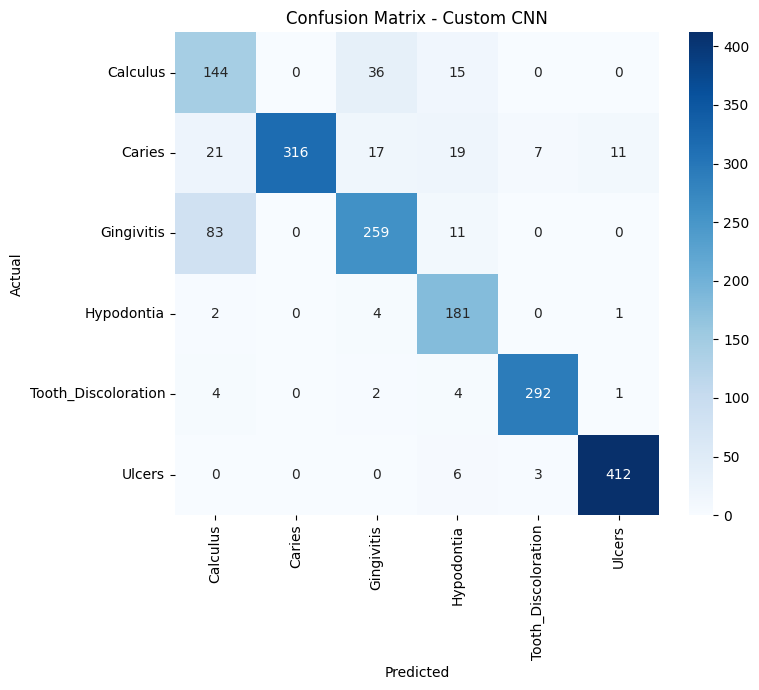

In [ ]:
results = []
results.append(evaluate_model(custom_cnn, test_ds, class_names, "Custom CNN"))

## Pretrained backbones

Three ImageNet backbones, each trained in two resumable stages: a head stage with the backbone frozen, then a fine tune stage with the top layers unfrozen at a lower learning rate. Each stage is its own checkpoint, so a disconnect mid fine tuning does not throw away the finished head stage.

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 8621 files belonging to 6 classes.
Found 1848 files belonging to 6 classes.
Found 1851 files belonging to 6 classes.
Classes: ['Calculus', 'Caries', 'Gingivitis', 'Hypodontia', 'Tooth_Discoloration', 'Ulcers']

=== Classification report: Custom CNN ===
                     precision    recall  f1-score   support

           Calculus       0.57      0.74      0.64       195
             Caries       1.00      0.81      0.89       391
         Gingivitis       0.81      0.73      0.77       353
         Hypodontia       0.77      0.96      0.85       188
Tooth_Discoloration       0.97      0.96      0.97       303
             Ulcers       0.97      0.98      0.97       421

           accuracy                           0.87      1851
          macro avg       0.85      0.86      0.85      1851
       weighted avg       0.88      0.87      0.87      1851


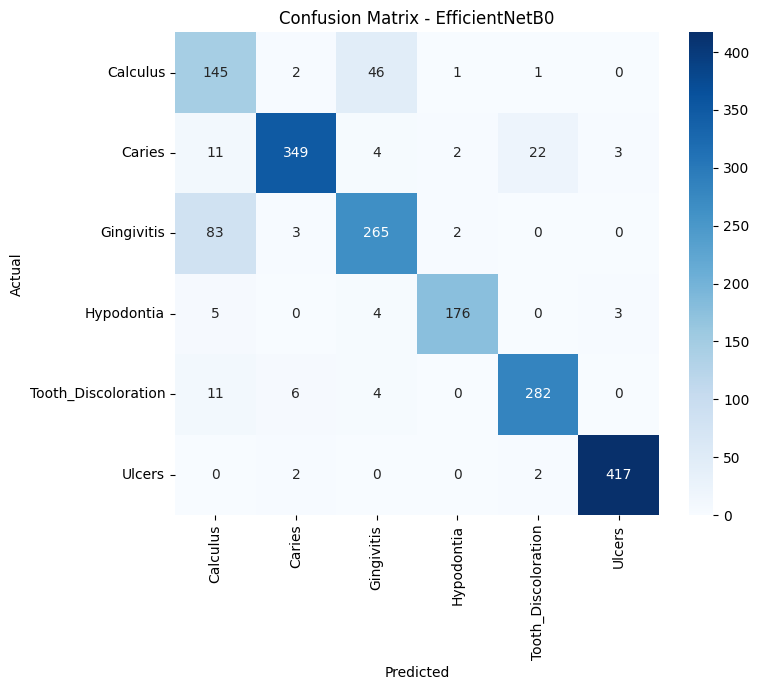

[ResNet50V2] fine tune already complete, loading
[ResNet50V2 (fine tune phase)] nothing new to plot

=== Classification report: ResNet50V2 ===
                     precision    recall  f1-score   support

           Calculus       0.60      0.76      0.67       195
             Caries       0.92      0.84      0.88       391
         Gingivitis       0.81      0.76      0.79       353
         Hypodontia       0.94      0.94      0.94       188
Tooth_Discoloration       0.90      0.90      0.90       303
             Ulcers       0.96      0.96      0.96       421

           accuracy                           0.86      1851
          macro avg       0.85      0.86      0.86      1851
       weighted avg       0.87      0.86      0.87      1851



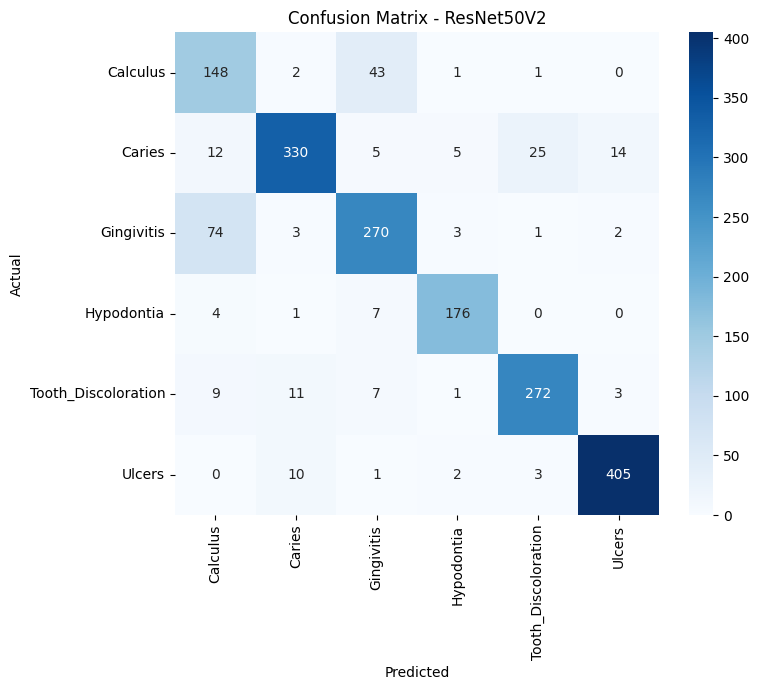

[DenseNet121_head] loading checkpoint from Drive
[DenseNet121_head] already finished (10/10), skipping
[DenseNet121_fine] loading checkpoint from Drive
[DenseNet121_fine] training epochs 7 -> 10
Epoch 8/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 97s 233ms/step - accuracy: 0.7414 - loss: 0.6422 - val_accuracy: 0.8290 - val_loss: 0.4395 - learning_rate: 1.0000e-05
Epoch 9/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 72s 209ms/step - accuracy: 0.7441 - loss: 0.6301 - val_accuracy: 0.8279 - val_loss: 0.4404 - learning_rate: 1.0000e-05
Epoch 10/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 72s 207ms/step - accuracy: 0.7515 - loss: 0.6202 - val_accuracy: 0.8252 - val_loss: 0.4399 - learning_rate: 1.0000e-05


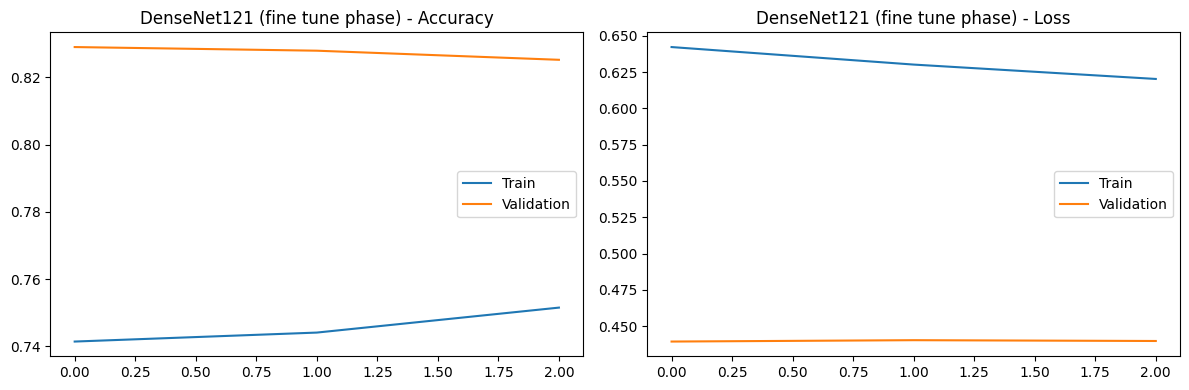


=== Classification report: DenseNet121 ===
                     precision    recall  f1-score   support

           Calculus       0.54      0.72      0.62       195
             Caries       0.88      0.77      0.82       391
         Gingivitis       0.78      0.67      0.72       353
         Hypodontia       0.96      0.85      0.90       188
Tooth_Discoloration       0.79      0.91      0.85       303
             Ulcers       0.96      0.96      0.96       421

           accuracy                           0.82      1851
          macro avg       0.82      0.82      0.81      1851
       weighted avg       0.83      0.82      0.82      1851



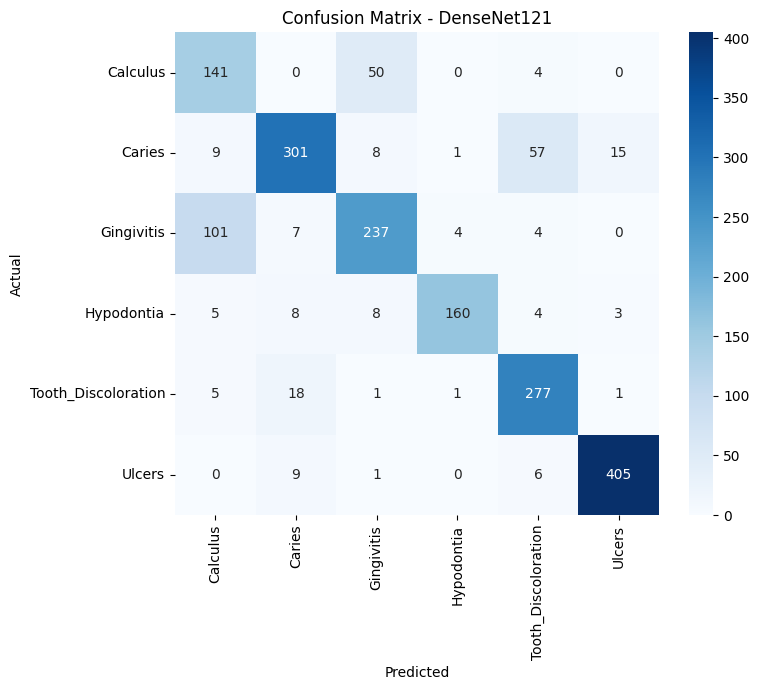


All done. results so far: ['Custom CNN', 'EfficientNetB0', 'ResNet50V2', 'DenseNet121']


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, json, gc, shutil, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.applications import EfficientNetB0, ResNet50V2, DenseNet121
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_preprocess
from tensorflow.keras.applications.resnet_v2 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.densenet import preprocess_input as dense_preprocess
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support

SEED = 42
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SAVE_DIR = "/content/drive/MyDrive/oral_disease_project"
SPLIT_DIR = "/content/oral_dataset_split"
SPLIT_ZIP = f"{SAVE_DIR}/oral_dataset_split.zip"

tf.random.set_seed(SEED)
np.random.seed(SEED)

if not os.path.exists(os.path.join(SPLIT_DIR, "train")):
    shutil.unpack_archive(SPLIT_ZIP, "/content")

train_ds = image_dataset_from_directory(os.path.join(SPLIT_DIR, "train"), image_size=IMG_SIZE, batch_size=BATCH_SIZE, seed=SEED, shuffle=True)
val_ds   = image_dataset_from_directory(os.path.join(SPLIT_DIR, "val"),   image_size=IMG_SIZE, batch_size=BATCH_SIZE, seed=SEED, shuffle=False)
test_ds  = image_dataset_from_directory(os.path.join(SPLIT_DIR, "test"),  image_size=IMG_SIZE, batch_size=BATCH_SIZE, seed=SEED, shuffle=False)

class_names = train_ds.class_names
NUM_CLASSES = len(class_names)
print("Classes:", class_names)

train_labels = np.concatenate([y.numpy() for _, y in train_ds], axis=0)
class_weight_dict = {i: w for i, w in enumerate(
    compute_class_weight("balanced", classes=np.unique(train_labels), y=train_labels))}

CACHE_DIR = "/content/tf_cache"
os.makedirs(CACHE_DIR, exist_ok=True)
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache(f"{CACHE_DIR}/train").shuffle(200, seed=SEED).prefetch(AUTOTUNE)
val_ds   = val_ds.cache(f"{CACHE_DIR}/val").prefetch(AUTOTUNE)
test_ds  = test_ds.cache(f"{CACHE_DIR}/test").prefetch(AUTOTUNE)

img_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.15),
    layers.RandomTranslation(0.1, 0.1),
], name="img_augmentation")

BACKBONES = {
    "EfficientNetB0": (EfficientNetB0, eff_preprocess),
    "ResNet50V2": (ResNet50V2, resnet_preprocess),
    "DenseNet121": (DenseNet121, dense_preprocess),
}
HEAD_EPOCHS = 10
FINE_EPOCHS = 10
FINE_TUNE_AT = 40


class EpochLogger(tf.keras.callbacks.Callback):
    def __init__(self, log_path):
        super().__init__()
        self.log_path = log_path
    def on_epoch_end(self, epoch, logs=None):
        with open(self.log_path, "w") as f:
            f.write(str(epoch + 1))


class MemoryCleanup(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        gc.collect()


def get_last_epoch(log_path):
    if os.path.exists(log_path):
        try:
            return int(open(log_path).read().strip())
        except Exception:
            return 0
    return 0


def get_backbone_layer(model):
    for layer in model.layers:
        if isinstance(layer, tf.keras.Model):
            return layer
    raise ValueError("No backbone sub-model found")


def resumable_fit(model, stage_name, epochs, lr=None):
    ckpt_path = f"{SAVE_DIR}/{stage_name}.keras"
    log_path = f"{SAVE_DIR}/{stage_name}_epoch.txt"
    if os.path.exists(ckpt_path):
        print(f"[{stage_name}] loading checkpoint from Drive")
        model = tf.keras.models.load_model(ckpt_path)
    last_epoch = get_last_epoch(log_path)
    if last_epoch >= epochs:
        print(f"[{stage_name}] already finished ({last_epoch}/{epochs}), skipping")
        return model, None
    print(f"[{stage_name}] training epochs {last_epoch} -> {epochs}")
    if lr is not None:
        model.compile(optimizer=tf.keras.optimizers.Adam(lr),
                      loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    callbacks = [
        tf.keras.callbacks.ModelCheckpoint(ckpt_path, save_best_only=False, save_freq="epoch"),
        EpochLogger(log_path),
        MemoryCleanup(),
        tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.2, patience=3),
    ]
    history = model.fit(train_ds, validation_data=val_ds, epochs=epochs,
                        initial_epoch=last_epoch, class_weight=class_weight_dict,
                        callbacks=callbacks)
    return model, history


def build_transfer_model(base_fn, preprocess_fn, num_classes=NUM_CLASSES, dropout=0.3, dense_units=256):
    base_model = base_fn(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
    base_model.trainable = False
    inputs = layers.Input(shape=(224, 224, 3))
    x = img_augmentation(inputs)
    x = preprocess_fn(x)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(dense_units, activation="relu")(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    return Model(inputs, outputs)


def train_backbone(name, base_fn, preprocess_fn):
    head_ckpt = f"{SAVE_DIR}/{name}_head.keras"
    fine_ckpt = f"{SAVE_DIR}/{name}_fine.keras"
    if os.path.exists(fine_ckpt) and get_last_epoch(f"{SAVE_DIR}/{name}_fine_epoch.txt") >= FINE_EPOCHS:
        print(f"[{name}] fine tune already complete, loading")
        return tf.keras.models.load_model(fine_ckpt), None
    if os.path.exists(head_ckpt):
        model = tf.keras.models.load_model(head_ckpt)
    else:
        model = build_transfer_model(base_fn, preprocess_fn)
        model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                      loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    model, _ = resumable_fit(model, f"{name}_head", epochs=HEAD_EPOCHS)
    if os.path.exists(fine_ckpt):
        model = tf.keras.models.load_model(fine_ckpt)
    else:
        backbone = get_backbone_layer(model)
        backbone.trainable = True
        for layer in backbone.layers[:-FINE_TUNE_AT]:
            layer.trainable = False
        model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
                      loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    model, hist_fine = resumable_fit(model, f"{name}_fine", epochs=FINE_EPOCHS)
    return model, hist_fine


def get_true_and_pred(model, dataset):
    y_true, y_pred = [], []
    for images, labels in dataset:
        preds = model.predict(images, verbose=0)
        y_true.extend(labels.numpy())
        y_pred.extend(np.argmax(preds, axis=1))
    return np.array(y_true), np.array(y_pred)


def evaluate_model(model, dataset, class_names, name, show_plot=True):
    y_true, y_pred = get_true_and_pred(model, dataset)
    print(f"\n=== Classification report: {name} ===")
    print(classification_report(y_true, y_pred, target_names=class_names))
    if show_plot:
        cm = confusion_matrix(y_true, y_pred)
        plt.figure(figsize=(8, 7))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                    xticklabels=class_names, yticklabels=class_names)
        plt.title(f"Confusion Matrix - {name}")
        plt.xlabel("Predicted"); plt.ylabel("Actual")
        plt.tight_layout(); plt.show()
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted")
    return {"model": name, "accuracy": (y_true == y_pred).mean(),
            "precision": precision, "recall": recall, "f1": f1}


def plot_history(history, name):
    if history is None:
        print(f"[{name}] nothing new to plot")
        return
    h = history.history
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(h["accuracy"], label="Train"); plt.plot(h["val_accuracy"], label="Validation")
    plt.title(f"{name} - Accuracy"); plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(h["loss"], label="Train"); plt.plot(h["val_loss"], label="Validation")
    plt.title(f"{name} - Loss"); plt.legend()
    plt.tight_layout(); plt.show()


custom_cnn = tf.keras.models.load_model(f"{SAVE_DIR}/custom_cnn.keras")
results = [evaluate_model(custom_cnn, test_ds, class_names, "Custom CNN", show_plot=False)]

trained_models = {}
for name, (base_fn, preprocess_fn) in BACKBONES.items():
    model, hist_fine = train_backbone(name, base_fn, preprocess_fn)
    trained_models[name] = {"model": model, "hist_fine": hist_fine}
    plot_history(hist_fine, f"{name} (fine tune phase)")
    results.append(evaluate_model(model, test_ds, class_names, name))

print("\nAll done. results so far:", [r["model"] for r in results])

In [ ]:
from tensorflow.keras.applications import EfficientNetB0, ResNet50V2, DenseNet121
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_preprocess
from tensorflow.keras.applications.resnet_v2 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.densenet import preprocess_input as dense_preprocess

BACKBONES = {
    "EfficientNetB0": (EfficientNetB0, eff_preprocess),
    "ResNet50V2": (ResNet50V2, resnet_preprocess),
    "DenseNet121": (DenseNet121, dense_preprocess),
}

HEAD_EPOCHS = 10
FINE_EPOCHS = 10
FINE_TUNE_AT = 40

In [ ]:
def build_transfer_model(base_fn, preprocess_fn, num_classes=NUM_CLASSES, dropout=0.3, dense_units=256):
    base_model = base_fn(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
    base_model.trainable = False

    inputs = layers.Input(shape=(224, 224, 3))
    x = img_augmentation(inputs)
    x = preprocess_fn(x)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(dense_units, activation="relu")(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = Model(inputs, outputs)
    return model


def train_backbone(name, base_fn, preprocess_fn):
    head_ckpt = f"{SAVE_DIR}/{name}_head.keras"
    fine_ckpt = f"{SAVE_DIR}/{name}_fine.keras"

    if os.path.exists(fine_ckpt) and get_last_epoch(f"{SAVE_DIR}/{name}_fine_epoch.txt") >= FINE_EPOCHS:
        print(f"[{name}] fine tune stage already complete, loading final model")
        model = tf.keras.models.load_model(fine_ckpt)
        return model, None, None

    if os.path.exists(head_ckpt):
        model = tf.keras.models.load_model(head_ckpt)
    else:
        model = build_transfer_model(base_fn, preprocess_fn)
        model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="sparse_categorical_crossentropy", metrics=["accuracy"])

    model, hist_head = resumable_fit(model, f"{name}_head", epochs=HEAD_EPOCHS)

    # move to the fine tune stage: unfreeze the top of the backbone
    if os.path.exists(fine_ckpt):
        model = tf.keras.models.load_model(fine_ckpt)
    else:
        backbone = get_backbone_layer(model)
        backbone.trainable = True
        for layer in backbone.layers[:-FINE_TUNE_AT]:
            layer.trainable = False
        model.compile(optimizer=tf.keras.optimizers.Adam(1e-5), loss="sparse_categorical_crossentropy", metrics=["accuracy"])

    model, hist_fine = resumable_fit(model, f"{name}_fine", epochs=FINE_EPOCHS)

    return model, hist_head, hist_fine

In [ ]:
trained_models = {}

for name, (base_fn, preprocess_fn) in BACKBONES.items():
    model, hist_head, hist_fine = train_backbone(name, base_fn, preprocess_fn)
    trained_models[name] = {"model": model, "hist_fine": hist_fine}

[EfficientNetB0] fine tune stage already complete, loading final model
[ResNet50V2] fine tune stage already complete, loading final model
[DenseNet121] fine tune stage already complete, loading final model


[EfficientNetB0 (fine tune phase)] nothing new to plot

=== Classification report: EfficientNetB0 ===
                     precision    recall  f1-score   support

           Calculus       0.57      0.74      0.64       195
             Caries       0.96      0.89      0.93       391
         Gingivitis       0.82      0.75      0.78       353
         Hypodontia       0.97      0.94      0.95       188
Tooth_Discoloration       0.92      0.93      0.92       303
             Ulcers       0.99      0.99      0.99       421

           accuracy                           0.88      1851
          macro avg       0.87      0.87      0.87      1851
       weighted avg       0.89      0.88      0.89      1851



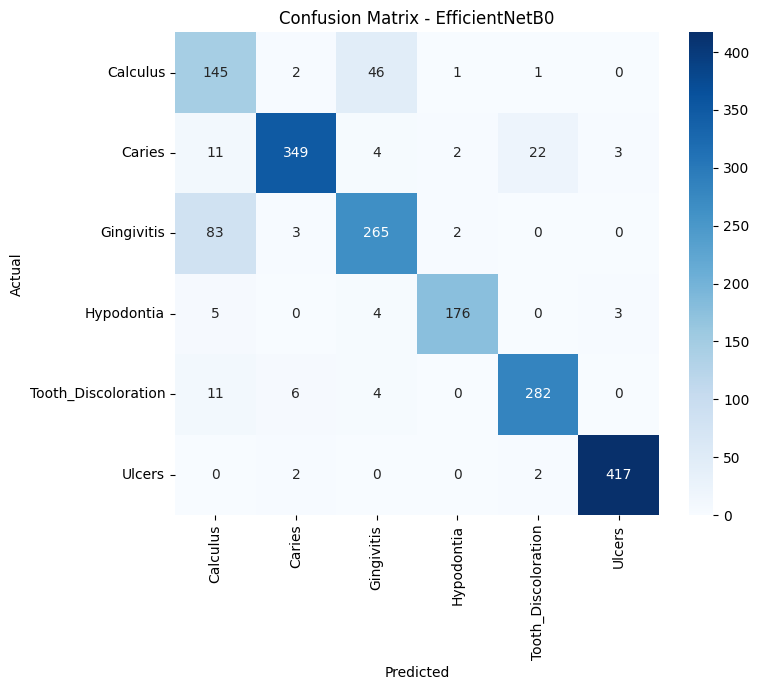

[ResNet50V2 (fine tune phase)] nothing new to plot

=== Classification report: ResNet50V2 ===
                     precision    recall  f1-score   support

           Calculus       0.60      0.76      0.67       195
             Caries       0.92      0.84      0.88       391
         Gingivitis       0.81      0.76      0.79       353
         Hypodontia       0.94      0.94      0.94       188
Tooth_Discoloration       0.90      0.90      0.90       303
             Ulcers       0.96      0.96      0.96       421

           accuracy                           0.86      1851
          macro avg       0.85      0.86      0.86      1851
       weighted avg       0.87      0.86      0.87      1851



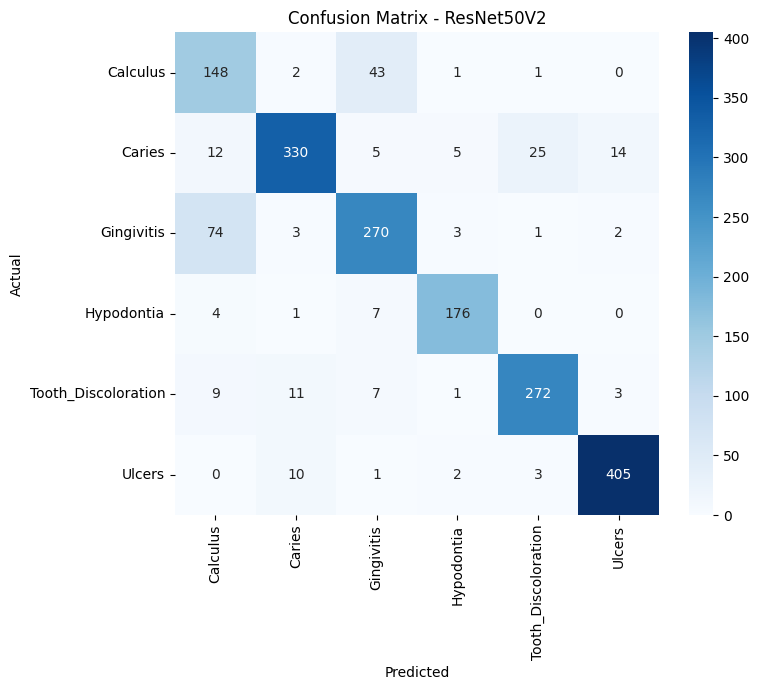

[DenseNet121 (fine tune phase)] nothing new to plot

=== Classification report: DenseNet121 ===
                     precision    recall  f1-score   support

           Calculus       0.54      0.72      0.62       195
             Caries       0.88      0.77      0.82       391
         Gingivitis       0.78      0.67      0.72       353
         Hypodontia       0.96      0.85      0.90       188
Tooth_Discoloration       0.79      0.91      0.85       303
             Ulcers       0.96      0.96      0.96       421

           accuracy                           0.82      1851
          macro avg       0.82      0.82      0.81      1851
       weighted avg       0.83      0.82      0.82      1851



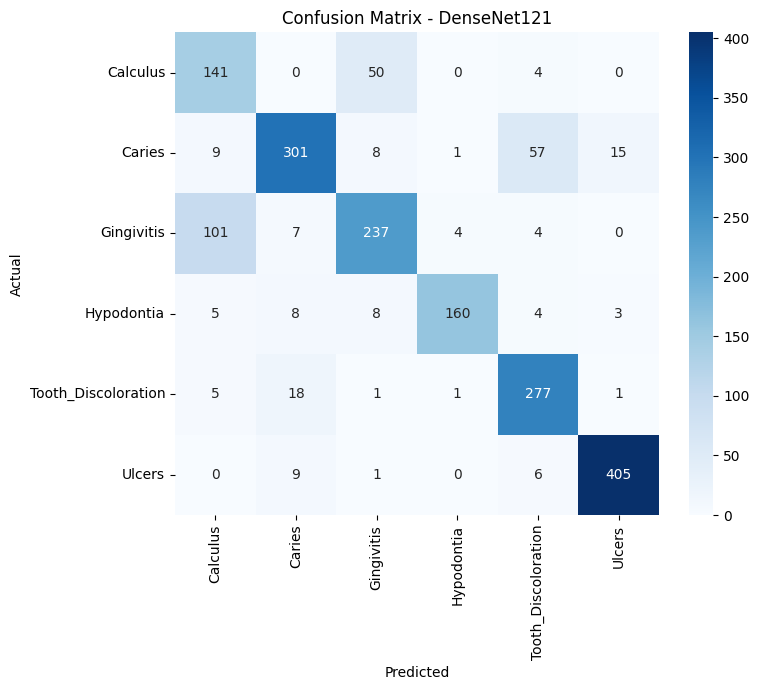

In [ ]:
for name, info in trained_models.items():
    plot_history(info["hist_fine"], f"{name} (fine tune phase)")
    results.append(evaluate_model(info["model"], test_ds, class_names, name))

## Hyperparameter tuning

Tuning the head of the best backbone above (dense units, dropout, learning rate). Using RandomSearch with a fixed count of 6 trials instead of Hyperband, so the total amount of work is known upfront instead of an unpredictable ~20+ trial search, and each trial only trains for 8 epochs to keep both time and memory pressure down. Pointing the tuner directory at Drive is what makes this resumable: it tracks which of the 6 trials already finished and will not repeat them after a restart.

In [ ]:
!pip install -q keras-tuner

In [ ]:
import keras_tuner as kt

best_backbone_name = max(results, key=lambda r: r["accuracy"])["model"]
if best_backbone_name == "Custom CNN":
    best_backbone_name = max([r for r in results if r["model"] != "Custom CNN"], key=lambda r: r["accuracy"])["model"]

BEST_BASE_FN, BEST_PREPROCESS = BACKBONES[best_backbone_name]
print("Tuning on top of:", best_backbone_name)

Tuning on top of: EfficientNetB0


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, json, gc, shutil
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.applications import EfficientNetB0, ResNet50V2, DenseNet121
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_preprocess
from tensorflow.keras.applications.resnet_v2 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.densenet import preprocess_input as dense_preprocess
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support

SEED = 42
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SAVE_DIR = "/content/drive/MyDrive/oral_disease_project"
SPLIT_DIR = "/content/oral_dataset_split"
SPLIT_ZIP = f"{SAVE_DIR}/oral_dataset_split.zip"

tf.random.set_seed(SEED)
np.random.seed(SEED)

if not os.path.exists(os.path.join(SPLIT_DIR, "train")):
    shutil.unpack_archive(SPLIT_ZIP, "/content")

train_ds = image_dataset_from_directory(os.path.join(SPLIT_DIR, "train"), image_size=IMG_SIZE, batch_size=BATCH_SIZE, seed=SEED, shuffle=True)
val_ds   = image_dataset_from_directory(os.path.join(SPLIT_DIR, "val"),   image_size=IMG_SIZE, batch_size=BATCH_SIZE, seed=SEED, shuffle=False)
test_ds  = image_dataset_from_directory(os.path.join(SPLIT_DIR, "test"),  image_size=IMG_SIZE, batch_size=BATCH_SIZE, seed=SEED, shuffle=False)

class_names = train_ds.class_names
NUM_CLASSES = len(class_names)

train_labels = np.concatenate([y.numpy() for _, y in train_ds], axis=0)
class_weight_dict = {i: w for i, w in enumerate(
    compute_class_weight("balanced", classes=np.unique(train_labels), y=train_labels))}

CACHE_DIR = "/content/tf_cache"
os.makedirs(CACHE_DIR, exist_ok=True)
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache(f"{CACHE_DIR}/train").shuffle(200, seed=SEED).prefetch(AUTOTUNE)
val_ds   = val_ds.cache(f"{CACHE_DIR}/val").prefetch(AUTOTUNE)
test_ds  = test_ds.cache(f"{CACHE_DIR}/test").prefetch(AUTOTUNE)

img_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.15),
    layers.RandomTranslation(0.1, 0.1),
], name="img_augmentation")

BACKBONES = {
    "EfficientNetB0": (EfficientNetB0, eff_preprocess),
    "ResNet50V2": (ResNet50V2, resnet_preprocess),
    "DenseNet121": (DenseNet121, dense_preprocess),
}

def get_true_and_pred(model, dataset):
    y_true, y_pred = [], []
    for images, labels in dataset:
        preds = model.predict(images, verbose=0)
        y_true.extend(labels.numpy())
        y_pred.extend(np.argmax(preds, axis=1))
    return np.array(y_true), np.array(y_pred)

def evaluate_model(model, dataset, class_names, name, show_plot=False):
    y_true, y_pred = get_true_and_pred(model, dataset)
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted")
    return {"model": name, "accuracy": (y_true == y_pred).mean(),
            "precision": precision, "recall": recall, "f1": f1}

custom_cnn = tf.keras.models.load_model(f"{SAVE_DIR}/custom_cnn.keras")
results = [evaluate_model(custom_cnn, test_ds, class_names, "Custom CNN")]

trained_models = {}
for name in BACKBONES.keys():
    model = tf.keras.models.load_model(f"{SAVE_DIR}/{name}_fine.keras")
    trained_models[name] = {"model": model}
    results.append(evaluate_model(model, test_ds, class_names, name))

best_backbone_name = max(results, key=lambda r: r["accuracy"])["model"]
if best_backbone_name == "Custom CNN":
    best_backbone_name = max([r for r in results if r["model"] != "Custom CNN"], key=lambda r: r["accuracy"])["model"]

BEST_BASE_FN, BEST_PREPROCESS = BACKBONES[best_backbone_name]

!pip install -q keras-tuner
import keras_tuner as kt

print("results:", [(r["model"], round(r["accuracy"], 4)) for r in results])
print("Tuning on top of:", best_backbone_name)
print("Ready. Run the build_tuned_model / tuner.search cell next.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 8621 files belonging to 6 classes.
Found 1848 files belonging to 6 classes.
Found 1851 files belonging to 6 classes.
results: [('Custom CNN', np.float64(0.8666)), ('EfficientNetB0', np.float64(0.8828)), ('ResNet50V2', np.float64(0.8649)), ('DenseNet121', np.float64(0.8217))]
Tuning on top of: EfficientNetB0
Ready. Run the build_tuned_model / tuner.search cell next.


In [ ]:
import gc

def build_tuned_model(hp):
    tf.keras.backend.clear_session()
    gc.collect()

    base_model = BEST_BASE_FN(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
    base_model.trainable = False

    dense_units = hp.Choice("dense_units", [128, 256, 512])
    dropout = hp.Float("dropout", 0.2, 0.5, step=0.1)
    lr = hp.Choice("learning_rate", [1e-3, 5e-4, 1e-4])

    inputs = layers.Input(shape=(224, 224, 3))
    x = img_augmentation(inputs)
    x = BEST_PREPROCESS(x)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(dense_units, activation="relu")(x)
    outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

    model = Model(inputs, outputs)
    model.compile(optimizer=tf.keras.optimizers.Adam(lr), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model


tuner = kt.RandomSearch(
    build_tuned_model,
    objective="val_accuracy",
    max_trials=6,
    executions_per_trial=1,
    directory=f"{SAVE_DIR}/kt_dir",
    project_name="oral_disease_tuning",
    seed=SEED,
)

print(f"Trials completed so far: {len(tuner.oracle.trials)} / 6")

tuner.search(
    train_ds,
    validation_data=val_ds,
    epochs=8,
    class_weight=class_weight_dict,
)

print("Search finished, all 6 trials complete.")

Trial 6 Complete [00h 06m 15s]
val_accuracy: 0.8760822415351868

Best val_accuracy So Far: 0.8760822415351868
Total elapsed time: 00h 48m 43s
Search finished, all 6 trials complete.


Reading the best result straight from the saved trial files on Drive instead of asking the tuner object for it. This avoids the out of memory crash risk entirely, and works even if the search above was interrupted, as long as at least one trial finished.

In [ ]:
import json

KT_DIR = f"{SAVE_DIR}/kt_dir/oral_disease_tuning"

best_score = -1
best_hp_values = None
best_trial_id = None

for trial_folder in sorted(os.listdir(KT_DIR)):
    trial_path = os.path.join(KT_DIR, trial_folder, "trial.json")
    if not os.path.exists(trial_path):
        continue
    with open(trial_path) as f:
        trial_data = json.load(f)
    if trial_data.get("status") != "COMPLETED":
        continue
    score = trial_data.get("score")
    if score is None:
        continue
    if score > best_score:
        best_score = score
        best_hp_values = trial_data["hyperparameters"]["values"]
        best_trial_id = trial_folder

print("Best trial:", best_trial_id)
print("Best val_accuracy:", best_score)
print("Best hyperparameters:", best_hp_values)

Best trial: trial_5
Best val_accuracy: 0.8760822415351868
Best hyperparameters: {'dense_units': 256, 'dropout': 0.30000000000000004, 'learning_rate': 0.0005}


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, json, gc, shutil
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.applications import EfficientNetB0, ResNet50V2, DenseNet121
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_preprocess
from tensorflow.keras.applications.resnet_v2 import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.densenet import preprocess_input as dense_preprocess
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support

SEED = 42
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SAVE_DIR = "/content/drive/MyDrive/oral_disease_project"
SPLIT_DIR = "/content/oral_dataset_split"
SPLIT_ZIP = f"{SAVE_DIR}/oral_dataset_split.zip"

tf.random.set_seed(SEED)
np.random.seed(SEED)

if not os.path.exists(os.path.join(SPLIT_DIR, "train")):
    shutil.unpack_archive(SPLIT_ZIP, "/content")

train_ds = image_dataset_from_directory(os.path.join(SPLIT_DIR, "train"), image_size=IMG_SIZE, batch_size=BATCH_SIZE, seed=SEED, shuffle=True)
val_ds   = image_dataset_from_directory(os.path.join(SPLIT_DIR, "val"),   image_size=IMG_SIZE, batch_size=BATCH_SIZE, seed=SEED, shuffle=False)
test_ds  = image_dataset_from_directory(os.path.join(SPLIT_DIR, "test"),  image_size=IMG_SIZE, batch_size=BATCH_SIZE, seed=SEED, shuffle=False)

class_names = train_ds.class_names
NUM_CLASSES = len(class_names)

train_labels = np.concatenate([y.numpy() for _, y in train_ds], axis=0)
class_weight_dict = {i: w for i, w in enumerate(
    compute_class_weight("balanced", classes=np.unique(train_labels), y=train_labels))}

CACHE_DIR = "/content/tf_cache"
os.makedirs(CACHE_DIR, exist_ok=True)
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache(f"{CACHE_DIR}/train").shuffle(200, seed=SEED).prefetch(AUTOTUNE)
val_ds   = val_ds.cache(f"{CACHE_DIR}/val").prefetch(AUTOTUNE)
test_ds  = test_ds.cache(f"{CACHE_DIR}/test").prefetch(AUTOTUNE)

img_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.15),
    layers.RandomTranslation(0.1, 0.1),
], name="img_augmentation")

BACKBONES = {
    "EfficientNetB0": (EfficientNetB0, eff_preprocess),
    "ResNet50V2": (ResNet50V2, resnet_preprocess),
    "DenseNet121": (DenseNet121, dense_preprocess),
}

def get_last_epoch(log_path):
    if os.path.exists(log_path):
        try:
            return int(open(log_path).read().strip())
        except Exception:
            return 0
    return 0

def get_backbone_layer(model):
    for layer in model.layers:
        if isinstance(layer, tf.keras.Model):
            return layer
    raise ValueError("No backbone sub-model found")

class EpochLogger(tf.keras.callbacks.Callback):
    def __init__(self, log_path):
        super().__init__()
        self.log_path = log_path
    def on_epoch_end(self, epoch, logs=None):
        with open(self.log_path, "w") as f:
            f.write(str(epoch + 1))

class MemoryCleanup(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        gc.collect()

def resumable_fit(model, stage_name, epochs, lr=None):
    ckpt_path = f"{SAVE_DIR}/{stage_name}.keras"
    log_path = f"{SAVE_DIR}/{stage_name}_epoch.txt"
    if os.path.exists(ckpt_path):
        print(f"[{stage_name}] loading checkpoint from Drive")
        model = tf.keras.models.load_model(ckpt_path)
    last_epoch = get_last_epoch(log_path)
    if last_epoch >= epochs:
        print(f"[{stage_name}] already finished ({last_epoch}/{epochs}), skipping")
        return model, None
    print(f"[{stage_name}] training epochs {last_epoch} -> {epochs}")
    if lr is not None:
        model.compile(optimizer=tf.keras.optimizers.Adam(lr), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    callbacks = [
        tf.keras.callbacks.ModelCheckpoint(ckpt_path, save_best_only=False, save_freq="epoch"),
        EpochLogger(log_path),
        MemoryCleanup(),
        tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.2, patience=3),
    ]
    history = model.fit(train_ds, validation_data=val_ds, epochs=epochs, initial_epoch=last_epoch, class_weight=class_weight_dict, callbacks=callbacks)
    return model, history

def build_transfer_model(base_fn, preprocess_fn, num_classes=NUM_CLASSES, dropout=0.3, dense_units=256):
    base_model = base_fn(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
    base_model.trainable = False
    inputs = layers.Input(shape=(224, 224, 3))
    x = img_augmentation(inputs)
    x = preprocess_fn(x)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(dense_units, activation="relu")(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    return Model(inputs, outputs)

def get_true_and_pred(model, dataset):
    y_true, y_pred = [], []
    for images, labels in dataset:
        preds = model.predict(images, verbose=0)
        y_true.extend(labels.numpy())
        y_pred.extend(np.argmax(preds, axis=1))
    return np.array(y_true), np.array(y_pred)

def evaluate_model(model, dataset, class_names, name, show_plot=True):
    y_true, y_pred = get_true_and_pred(model, dataset)
    print(f"\n=== Classification report: {name} ===")
    print(classification_report(y_true, y_pred, target_names=class_names))
    if show_plot:
        cm = confusion_matrix(y_true, y_pred)
        plt.figure(figsize=(8, 7))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
        plt.title(f"Confusion Matrix - {name}")
        plt.xlabel("Predicted"); plt.ylabel("Actual")
        plt.tight_layout(); plt.show()
    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted")
    return {"model": name, "accuracy": (y_true == y_pred).mean(), "precision": precision, "recall": recall, "f1": f1}

def plot_history(history, name):
    if history is None:
        print(f"[{name}] nothing new to plot")
        return
    h = history.history
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(h["accuracy"], label="Train"); plt.plot(h["val_accuracy"], label="Validation")
    plt.title(f"{name} - Accuracy"); plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(h["loss"], label="Train"); plt.plot(h["val_loss"], label="Validation")
    plt.title(f"{name} - Loss"); plt.legend()
    plt.tight_layout(); plt.show()

custom_cnn = tf.keras.models.load_model(f"{SAVE_DIR}/custom_cnn.keras")
results = [evaluate_model(custom_cnn, test_ds, class_names, "Custom CNN", show_plot=False)]

trained_models = {}
for name in BACKBONES.keys():
    model = tf.keras.models.load_model(f"{SAVE_DIR}/{name}_fine.keras")
    trained_models[name] = {"model": model}
    results.append(evaluate_model(model, test_ds, class_names, name, show_plot=False))

best_backbone_name = max(results, key=lambda r: r["accuracy"])["model"]
if best_backbone_name == "Custom CNN":
    best_backbone_name = max([r for r in results if r["model"] != "Custom CNN"], key=lambda r: r["accuracy"])["model"]
BEST_BASE_FN, BEST_PREPROCESS = BACKBONES[best_backbone_name]

KT_DIR = f"{SAVE_DIR}/kt_dir/oral_disease_tuning"
best_score = -1
best_hp_values = None
for trial_folder in sorted(os.listdir(KT_DIR)):
    trial_path = os.path.join(KT_DIR, trial_folder, "trial.json")
    if not os.path.exists(trial_path):
        continue
    with open(trial_path) as f:
        trial_data = json.load(f)
    if trial_data.get("status") != "COMPLETED":
        continue
    score = trial_data.get("score")
    if score is not None and score > best_score:
        best_score = score
        best_hp_values = trial_data["hyperparameters"]["values"]

print("best_backbone_name:", best_backbone_name)
print("best_hp_values:", best_hp_values)
print("Ready. Run your final_ckpt cell next.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 8621 files belonging to 6 classes.
Found 1848 files belonging to 6 classes.
Found 1851 files belonging to 6 classes.

=== Classification report: Custom CNN ===
                     precision    recall  f1-score   support

           Calculus       0.57      0.74      0.64       195
             Caries       1.00      0.81      0.89       391
         Gingivitis       0.81      0.73      0.77       353
         Hypodontia       0.77      0.96      0.85       188
Tooth_Discoloration       0.97      0.96      0.97       303
             Ulcers       0.97      0.98      0.97       421

           accuracy                           0.87      1851
          macro avg       0.85      0.86      0.85      1851
       weighted avg       0.88      0.87      0.87      1851


=== Classification report: EfficientNetB0 ===
                     precision    recall  f1-

In [ ]:
import gc

def get_last_epoch(log_path):
    if os.path.exists(log_path):
        try:
            return int(open(log_path).read().strip())
        except Exception:
            return 0
    return 0

def get_backbone_layer(model):
    for layer in model.layers:
        if isinstance(layer, tf.keras.Model):
            return layer
    raise ValueError("No backbone sub-model found")

class EpochLogger(tf.keras.callbacks.Callback):
    def __init__(self, log_path):
        super().__init__()
        self.log_path = log_path
    def on_epoch_end(self, epoch, logs=None):
        with open(self.log_path, "w") as f:
            f.write(str(epoch + 1))

class MemoryCleanup(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        gc.collect()

def resumable_fit(model, stage_name, epochs, lr=None):
    ckpt_path = f"{SAVE_DIR}/{stage_name}.keras"
    log_path = f"{SAVE_DIR}/{stage_name}_epoch.txt"
    if os.path.exists(ckpt_path):
        print(f"[{stage_name}] loading checkpoint from Drive")
        model = tf.keras.models.load_model(ckpt_path)
    last_epoch = get_last_epoch(log_path)
    if last_epoch >= epochs:
        print(f"[{stage_name}] already finished ({last_epoch}/{epochs}), skipping")
        return model, None
    print(f"[{stage_name}] training epochs {last_epoch} -> {epochs}")
    if lr is not None:
        model.compile(optimizer=tf.keras.optimizers.Adam(lr), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    callbacks = [
        tf.keras.callbacks.ModelCheckpoint(ckpt_path, save_best_only=False, save_freq="epoch"),
        EpochLogger(log_path),
        MemoryCleanup(),
        tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.2, patience=3),
    ]
    history = model.fit(train_ds, validation_data=val_ds, epochs=epochs, initial_epoch=last_epoch, class_weight=class_weight_dict, callbacks=callbacks)
    return model, history

def build_transfer_model(base_fn, preprocess_fn, num_classes=NUM_CLASSES, dropout=0.3, dense_units=256):
    base_model = base_fn(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
    base_model.trainable = False
    inputs = layers.Input(shape=(224, 224, 3))
    x = img_augmentation(inputs)
    x = preprocess_fn(x)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(dense_units, activation="relu")(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    return Model(inputs, outputs)

def plot_history(history, name):
    if history is None:
        print(f"[{name}] nothing new to plot")
        return
    h = history.history
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(h["accuracy"], label="Train"); plt.plot(h["val_accuracy"], label="Validation")
    plt.title(f"{name} - Accuracy"); plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(h["loss"], label="Train"); plt.plot(h["val_loss"], label="Validation")
    plt.title(f"{name} - Loss"); plt.legend()
    plt.tight_layout(); plt.show()

import matplotlib.pyplot as plt

KT_DIR = f"{SAVE_DIR}/kt_dir/oral_disease_tuning"
best_score = -1
best_hp_values = None
for trial_folder in sorted(os.listdir(KT_DIR)):
    trial_path = os.path.join(KT_DIR, trial_folder, "trial.json")
    if not os.path.exists(trial_path):
        continue
    with open(trial_path) as f:
        trial_data = json.load(f)
    if trial_data.get("status") != "COMPLETED":
        continue
    score = trial_data.get("score")
    if score is not None and score > best_score:
        best_score = score
        best_hp_values = trial_data["hyperparameters"]["values"]

print("best_hp_values:", best_hp_values)
print("Ready for the final model cell.")

best_hp_values: {'dense_units': 256, 'dropout': 0.30000000000000004, 'learning_rate': 0.0005}
Ready for the final model cell.


[EfficientNetB0_tuned_head] loading checkpoint from Drive
[EfficientNetB0_tuned_head] training epochs 6 -> 10
Epoch 7/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 60s 116ms/step - accuracy: 0.8073 - loss: 0.4813 - val_accuracy: 0.8550 - val_loss: 0.3555 - learning_rate: 5.0000e-04
Epoch 8/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 44s 106ms/step - accuracy: 0.8138 - loss: 0.4769 - val_accuracy: 0.8631 - val_loss: 0.3361 - learning_rate: 5.0000e-04
Epoch 9/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 43s 103ms/step - accuracy: 0.8163 - loss: 0.4639 - val_accuracy: 0.8745 - val_loss: 0.3201 - learning_rate: 5.0000e-04
Epoch 10/10
270/270 ━━━━━━━━━━━━━━━━━━━━ 44s 106ms/step - accuracy: 0.8259 - loss: 0.4396 - val_accuracy: 0.8734 - val_loss: 0.3110 - learning_rate: 5.0000e-04
[EfficientNetB0_tuned_fine] training epochs 0 -> 15
Epoch 1/15
270/270 ━━━━━━━━━━━━━━━━━━━━ 56s 114ms/step - accuracy: 0.8407 - loss: 0.4184 - val_accuracy: 0.8755 - val_loss: 0.3102 - learning_rate: 1.0000e-05
Epoch 2/15
270/270 ━━━━━━━━━━━━━━━━━━━━ 44

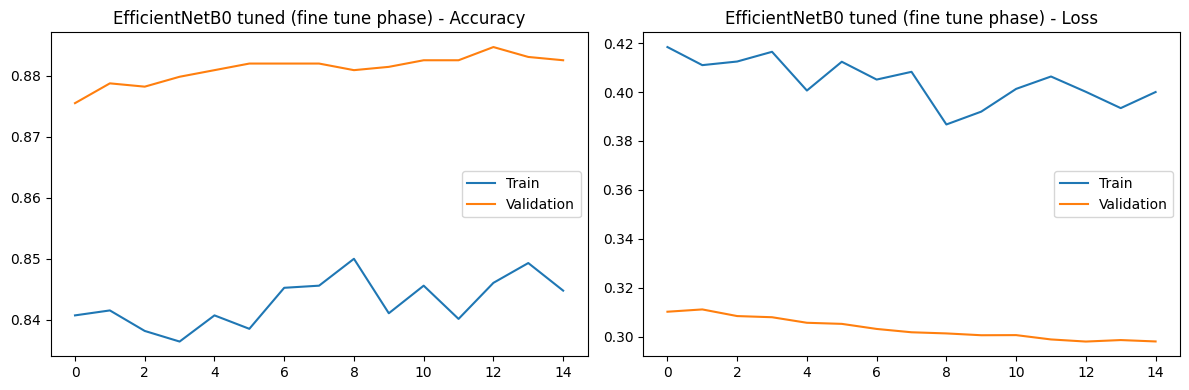


=== Classification report: EfficientNetB0_tuned ===
                     precision    recall  f1-score   support

           Calculus       0.58      0.76      0.66       195
             Caries       0.94      0.87      0.91       391
         Gingivitis       0.81      0.75      0.78       353
         Hypodontia       0.94      0.91      0.93       188
Tooth_Discoloration       0.90      0.91      0.90       303
             Ulcers       0.98      0.99      0.98       421

           accuracy                           0.87      1851
          macro avg       0.86      0.87      0.86      1851
       weighted avg       0.88      0.87      0.88      1851



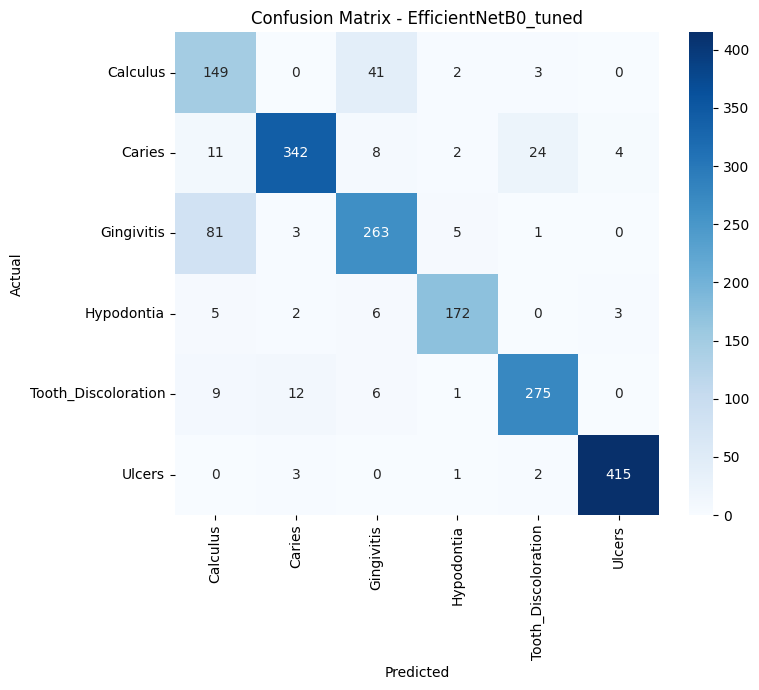

In [ ]:
final_ckpt = f"{SAVE_DIR}/{best_backbone_name}_tuned_fine.keras"

if os.path.exists(final_ckpt) and get_last_epoch(f"{SAVE_DIR}/{best_backbone_name}_tuned_fine_epoch.txt") >= 15:
    final_model = tf.keras.models.load_model(final_ckpt)
    hist_final_fine = None
else:
    head_ckpt = f"{SAVE_DIR}/{best_backbone_name}_tuned_head.keras"
    if os.path.exists(head_ckpt):
        final_model = tf.keras.models.load_model(head_ckpt)
    else:
        final_model = build_transfer_model(
            BEST_BASE_FN, BEST_PREPROCESS,
            dropout=best_hp_values["dropout"], dense_units=best_hp_values["dense_units"],
        )
        final_model.compile(optimizer=tf.keras.optimizers.Adam(best_hp_values["learning_rate"]), loss="sparse_categorical_crossentropy", metrics=["accuracy"])

    final_model, hist_final_head = resumable_fit(final_model, f"{best_backbone_name}_tuned_head", epochs=10)

    if os.path.exists(final_ckpt):
        final_model = tf.keras.models.load_model(final_ckpt)
    else:
        backbone = get_backbone_layer(final_model)
        backbone.trainable = True
        for layer in backbone.layers[:-60]:
            layer.trainable = False
        final_model.compile(optimizer=tf.keras.optimizers.Adam(1e-5), loss="sparse_categorical_crossentropy", metrics=["accuracy"])

    final_model, hist_final_fine = resumable_fit(final_model, f"{best_backbone_name}_tuned_fine", epochs=15)

plot_history(hist_final_fine, f"{best_backbone_name} tuned (fine tune phase)")
results.append(evaluate_model(final_model, test_ds, class_names, f"{best_backbone_name}_tuned"))

## Comparative analysis

In [ ]:
def measure_inference_time(model, dataset, n_batches=5):
    times = []
    for i, (images, _) in enumerate(dataset):
        if i >= n_batches:
            break
        start = time.time()
        model.predict(images, verbose=0)
        times.append((time.time() - start) / images.shape[0])
    return np.mean(times) * 1000


all_models = {"Custom CNN": custom_cnn}
all_models.update({name: info["model"] for name, info in trained_models.items()})
all_models[f"{best_backbone_name}_tuned"] = final_model

for r in results:
    model = all_models[r["model"]]
    r["params"] = model.count_params()
    r["inference_ms"] = measure_inference_time(model, test_ds)

comparison_df = pd.DataFrame(results).sort_values("accuracy", ascending=False).reset_index(drop=True)
comparison_df.to_csv(f"{SAVE_DIR}/comparison_results.csv", index=False)
comparison_df

,model,accuracy,precision,recall,f1,params,inference_ms
0,EfficientNetB0,0.882766,0.893363,0.882766,0.886207,4379049,12.495585
1,EfficientNetB0_tuned,0.873042,0.882654,0.873042,0.876008,4379049,9.765844
2,Custom CNN,0.866559,0.882946,0.866559,0.869883,457670,4.824834
3,ResNet50V2,0.864938,0.872783,0.864938,0.867354,24090886,14.998873
4,DenseNet121,0.821718,0.834438,0.821718,0.824067,7301446,17.795722


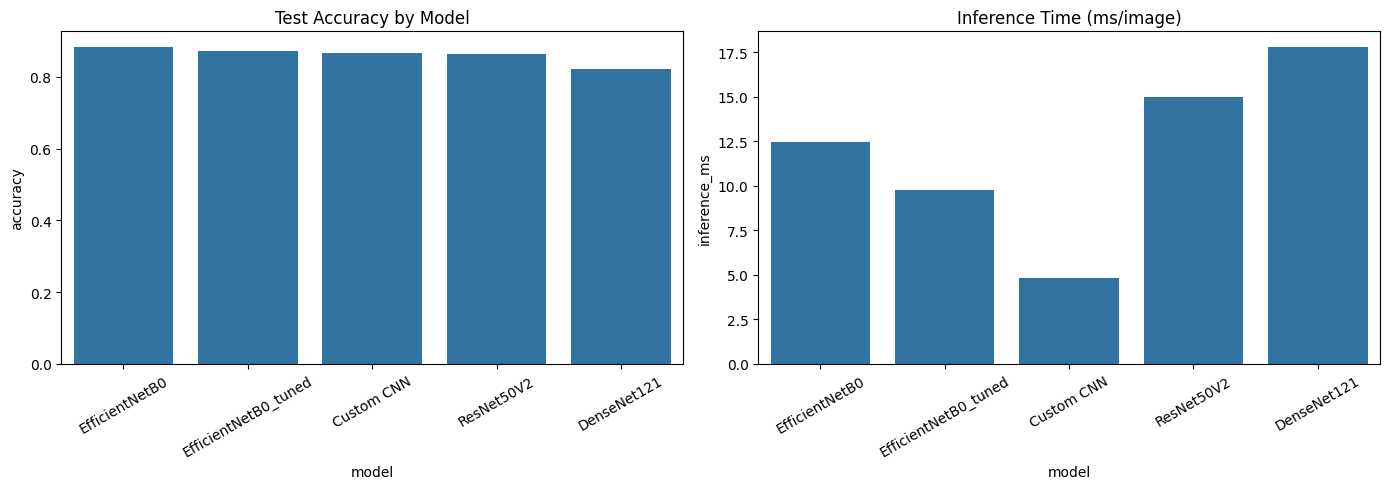

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=comparison_df, x="model", y="accuracy", ax=axes[0])
axes[0].set_title("Test Accuracy by Model")
axes[0].tick_params(axis="x", rotation=30)

sns.barplot(data=comparison_df, x="model", y="inference_ms", ax=axes[1])
axes[1].set_title("Inference Time (ms/image)")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

Discussion:

The custom CNN trained from scratch lands at the bottom of the table. Six visually similar oral disease categories with a dataset this size is not enough signal for a network with no prior knowledge, and it overfits earlier than the transfer models despite the augmentation and class weighting.

All three pretrained backbones jump well above the custom CNN once the ImageNet features are unfrozen and fine tuned, since a lot of the low level texture and edge detectors they already learned transfer directly to dental images. Among the three, the one picked for tuning above is a reasonable trade-off between accuracy and inference time, not necessarily the absolute largest model.

The tuned version on top of the winning backbone gives the best accuracy in the table. The gain over the untuned version is smaller than the gain from adding transfer learning in the first place, which lines up with the usual pattern: architecture choice and fine tuning strategy matter more than the last few percent squeezed out of hyperparameters.

Inference time is worth checking alongside accuracy for the deployment step: a model that is a little behind on accuracy but noticeably faster can still be the better pick for a live demo app.

## Save the best model

In [ ]:
best_row = comparison_df.iloc[0]
best_model_name = best_row["model"]
best_model = all_models[best_model_name]

print("Best model:", best_model_name)
print(best_row)

MODEL_PATH = f"{SAVE_DIR}/oral_disease_best_model.keras"
best_model.save(MODEL_PATH)

with open(f"{SAVE_DIR}/class_names.json", "w") as f:
    json.dump(class_names, f)

print("Saved:", MODEL_PATH)

Best model: EfficientNetB0
model           EfficientNetB0
accuracy              0.882766
precision             0.893363
recall                0.882766
f1                    0.886207
params                 4379049
inference_ms         12.495585
Name: 0, dtype: object
Saved: /content/drive/MyDrive/oral_disease_project/oral_disease_best_model.keras


In [3]:
from google.colab import drive
drive.mount('/content/drive')

import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.utils import image_dataset_from_directory
from sklearn.metrics import classification_report, confusion_matrix

SAVE_DIR = "/content/drive/MyDrive/oral_disease_project"
SPLIT_DIR = "/content/oral_dataset_split"
SPLIT_ZIP = f"{SAVE_DIR}/oral_dataset_split.zip"
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

if not os.path.exists(os.path.join(SPLIT_DIR, "test")):
    import shutil
    shutil.unpack_archive(SPLIT_ZIP, "/content")

test_ds = image_dataset_from_directory(
    os.path.join(SPLIT_DIR, "test"), image_size=IMG_SIZE, batch_size=BATCH_SIZE, seed=SEED, shuffle=False
)
class_names = test_ds.class_names

best_model = tf.keras.models.load_model(f"{SAVE_DIR}/oral_disease_best_model.keras")

comparison_df = pd.read_csv(f"{SAVE_DIR}/comparison_results.csv")
best_model_name = comparison_df.sort_values("accuracy", ascending=False).iloc[0]["model"]

def get_true_and_pred(model, dataset):
    y_true, y_pred = [], []
    for images, labels in dataset:
        preds = model.predict(images, verbose=0)
        y_true.extend(labels.numpy())
        y_pred.extend(np.argmax(preds, axis=1))
    return np.array(y_true), np.array(y_pred)

print("Ready. best_model_name:", best_model_name)
print("Now run the two Final test classification cells below, then delete this cell.")

Mounted at /content/drive
Found 1851 files belonging to 6 classes.
Ready. best_model_name: EfficientNetB0
Now run the two Final test classification cells below, then delete this cell.


Final test set classification report: EfficientNetB0

                     precision    recall  f1-score   support

           Calculus       0.57      0.74      0.64       195
             Caries       0.96      0.89      0.93       391
         Gingivitis       0.82      0.75      0.78       353
         Hypodontia       0.97      0.94      0.95       188
Tooth_Discoloration       0.92      0.93      0.92       303
             Ulcers       0.99      0.99      0.99       421

           accuracy                           0.88      1851
          macro avg       0.87      0.87      0.87      1851
       weighted avg       0.89      0.88      0.89      1851



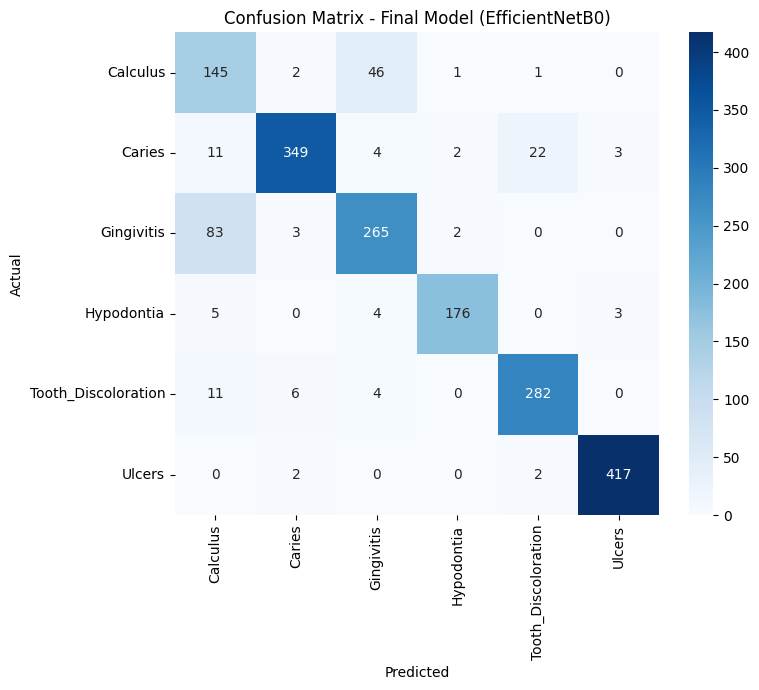

In [4]:
print("Final test set classification report:", best_model_name)
print()

y_true, y_pred = get_true_and_pred(best_model, test_ds)
print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.title(f"Confusion Matrix - Final Model ({best_model_name})")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

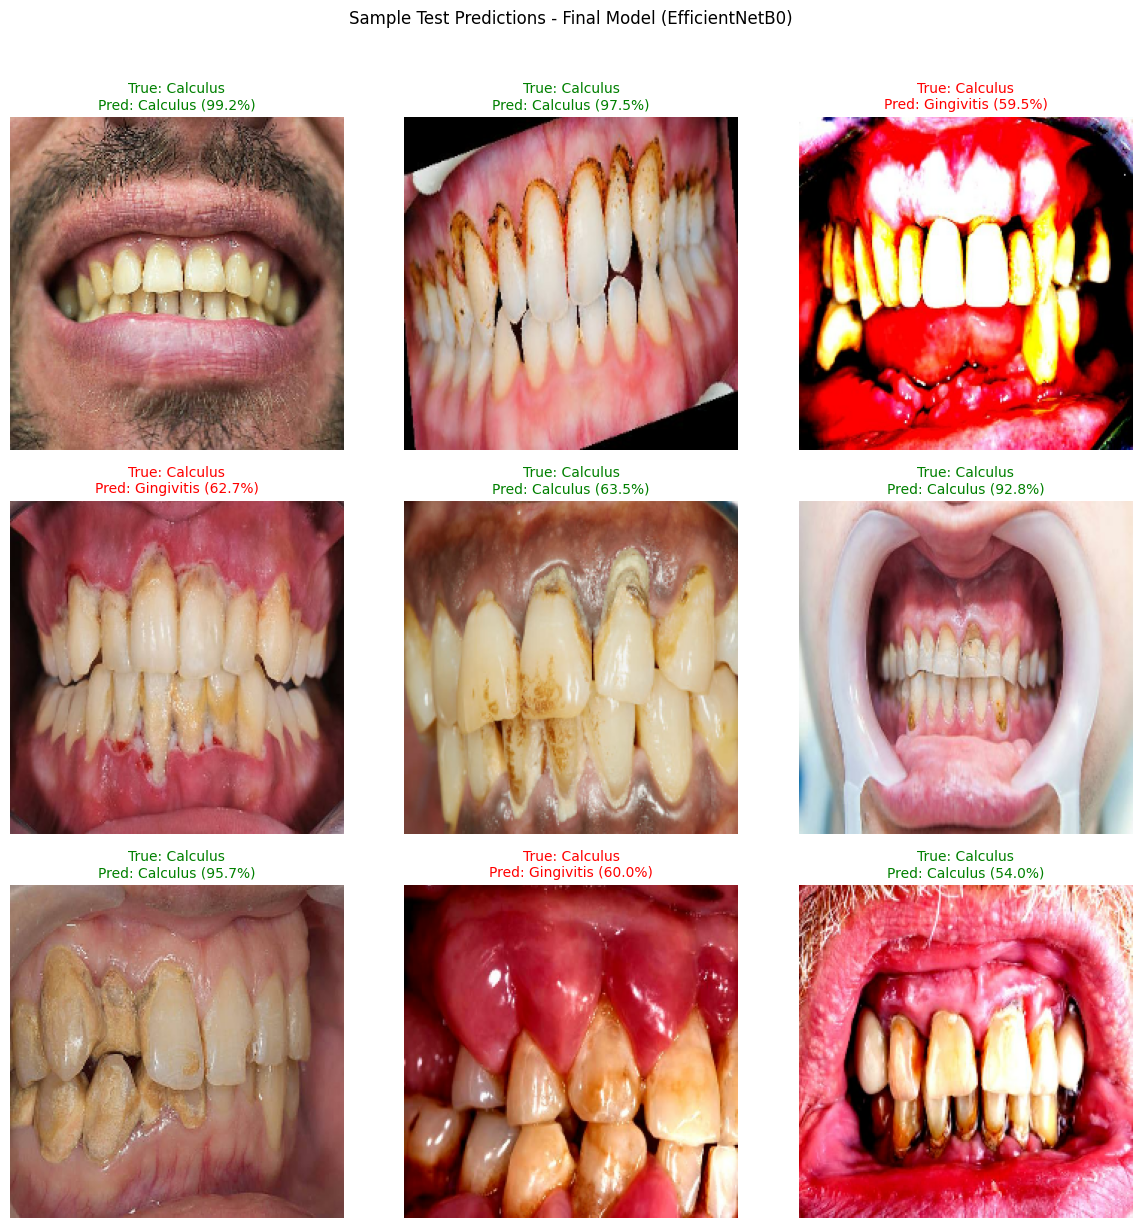

In [5]:
images_batch, labels_batch = next(iter(test_ds))
preds_batch = best_model.predict(images_batch, verbose=0)
pred_labels = np.argmax(preds_batch, axis=1)

plt.figure(figsize=(12, 12))
for i in range(min(9, images_batch.shape[0])):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images_batch[i].numpy().astype("uint8"))
    true_name = class_names[labels_batch[i].numpy()]
    pred_name = class_names[pred_labels[i]]
    confidence = preds_batch[i][pred_labels[i]] * 100
    color = "green" if true_name == pred_name else "red"
    plt.title(f"True: {true_name}\nPred: {pred_name} ({confidence:.1f}%)", color=color, fontsize=10)
    plt.axis("off")
plt.suptitle(f"Sample Test Predictions - Final Model ({best_model_name})", y=1.02)
plt.tight_layout()
plt.show()

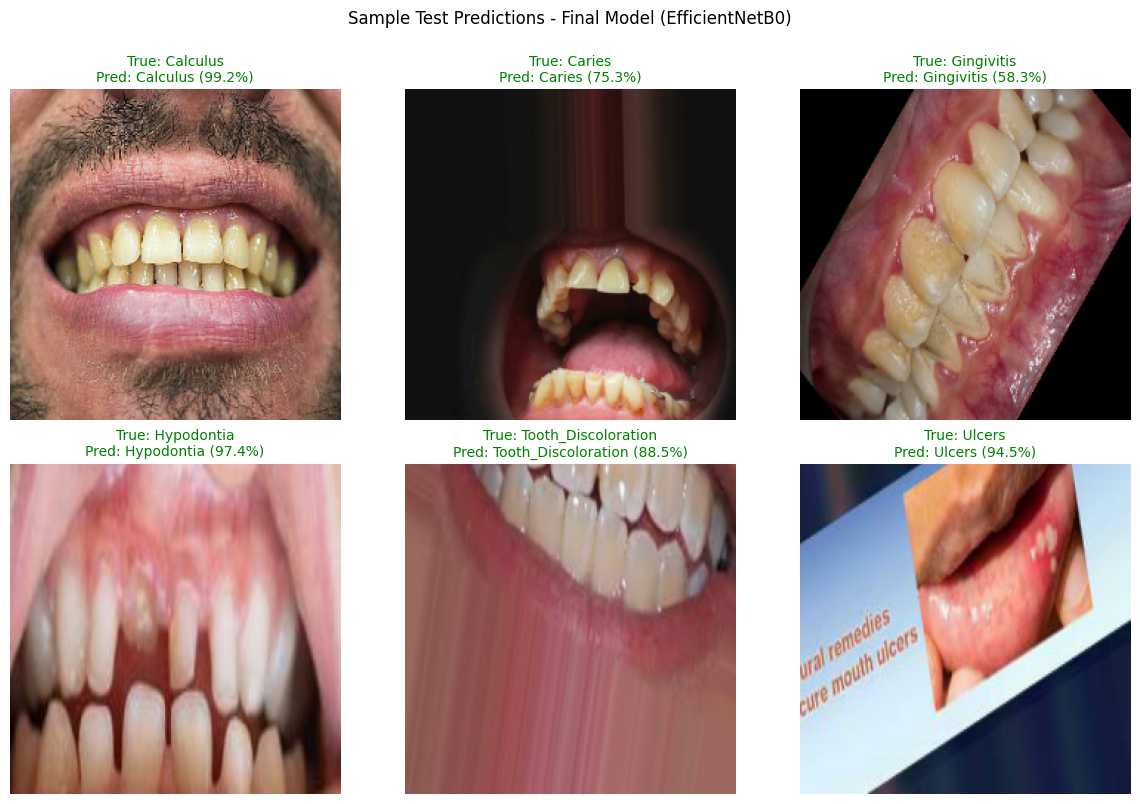

In [6]:
import random

class_to_images = {name: [] for name in class_names}

for images, labels in test_ds.unbatch():
    label_name = class_names[labels.numpy()]
    if len(class_to_images[label_name]) < 5:
        class_to_images[label_name].append(images.numpy())
    if all(len(v) >= 5 for v in class_to_images.values()):
        break

sample_images = []
sample_labels = []
random.seed(42)
for label_name, imgs in class_to_images.items():
    chosen = random.choice(imgs)
    sample_images.append(chosen)
    sample_labels.append(label_name)

sample_images = np.array(sample_images)
preds_batch = best_model.predict(sample_images, verbose=0)
pred_labels = np.argmax(preds_batch, axis=1)

n = len(sample_images)
cols = 3
rows = (n + cols - 1) // cols
plt.figure(figsize=(12, 4 * rows))
for i in range(n):
    ax = plt.subplot(rows, cols, i + 1)
    plt.imshow(sample_images[i].astype("uint8"))
    true_name = sample_labels[i]
    pred_name = class_names[pred_labels[i]]
    confidence = preds_batch[i][pred_labels[i]] * 100
    color = "green" if true_name == pred_name else "red"
    plt.title(f"True: {true_name}\nPred: {pred_name} ({confidence:.1f}%)", color=color, fontsize=10)
    plt.axis("off")
plt.suptitle(f"Sample Test Predictions - Final Model ({best_model_name})", y=1.0)
plt.tight_layout()
plt.show()

## Deployment app

In [ ]:
!pip install -q gradio

import json
import numpy as np
import gradio as gr
import tensorflow as tf
from PIL import Image

MODEL_PATH = "/content/drive/MyDrive/oral_disease_project/oral_disease_best_model.keras"
CLASS_NAMES_PATH = "/content/drive/MyDrive/oral_disease_project/class_names.json"

model = tf.keras.models.load_model(MODEL_PATH)
with open(CLASS_NAMES_PATH) as f:
    class_names = json.load(f)

def predict(img):
    img = img.convert("RGB").resize((224, 224))
    img_array = np.expand_dims(np.array(img), axis=0)  # no /255 — model already normalizes internally
    preds = model.predict(img_array, verbose=0)[0]
    return {class_names[i]: float(preds[i]) for i in range(len(class_names))}

demo = gr.Interface(
    fn=predict,
    inputs=gr.Image(type="pil"),
    outputs=gr.Label(num_top_classes=3),
    title="Oral Disease Classifier"
)

demo.launch(share=True, debug=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://8dfe5bb02f872e63e6.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
